In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
ROOT_PATH = "/content/drive/MyDrive/chiliSummerProject/src"
print(os.listdir(ROOT_PATH))
sys.path.append(ROOT_PATH)

['skel_cap_ipmg_map_logic.ipynb', 'generate_data.ipynb', 'data_exploration.ipynb', '__pycache__', 'helpers', 'define_model.py', 'data_stats.ipynb', 'model_train.ipynb', 'model_eval.ipynb']


In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import pprint as p
from define_model import *
from helpers.data_helpers import *
from helpers.metrics_helpers import *
from helpers.plot_helpers import *
from itertools import zip_longest
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

In [ ]:
p.pprint(tf.test.is_built_with_cuda())
print('*'*50)
p.pprint(tf.config.list_physical_devices('GPU'))
print('*'*50)
p.pprint(tf.test.gpu_device_name())

True
**************************************************
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
**************************************************
'/device:GPU:0'


In [ ]:
#set random seeds
seed = 0
random.seed(seed)
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)
#data paths
drive = 1 # 1 if on google drive, 0 if not
data_dir = "/content/drive/MyDrive/chiliSummerProject/data/" if drive else "../data/"
model_path = "/content/drive/MyDrive/chiliSummerProject/models/" if drive else "../models/"
chili_models = model_path + "chili_models/"
identifier_eth = "TouchPose_crossGestures"
data_path_eth = data_dir + "eth_data/"
data_path_chili= data_dir + "processed/native_mapped/map_7ms/"

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel = 'all')
un_normchili_data, skeleton_cols = read_data(keep_wrist=True, data_path=data_path_chili, norm_cap_img=False)
chili_data

before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True
before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-3.5045269768168508, 4.886331668271834, 2.68...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[-3.501236302847655, 4.888951391534825, 2.676...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[-3.498627416569385, 4.890008233131748, 2.670...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[-3.4946245642347185, 4.8883440492172, 2.6633...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[-3.4964263307378984, 4.883610171587114, 2.65...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-4.313244500394015, 4.563610503839469, 2.796...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-4.317725829162776, 4.567162207788467, 2.792...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-4.308631714288856, 4.551964985823625, 2.793...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-4.320031279868858, 4.552372550683785, 2.991...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


# Cross validation gesture model

In [ ]:
for g in chili_data.gesture.unique() :
    model = load_model(chili_models+'3d_models/crossGesture/cross'+str(g)+'.h5',compile=False)
    print('test set on '+g)
    data=load_data(chili_data, 'cross', None, seed, fold=g)
    y_true = data['test']['y']
    y_pred = model.predict(data['test']['X'],batch_size=32)
    auc = un_pck(mean,std)(y_true, y_pred).numpy()
    epe = un_epe(mean,std)(y_true, y_pred).numpy()
    edge = 63
    y_test_skeleton, y_out_skeleton = y_true[:,:edge], y_pred[:,:edge]
    epe_max = sorted_joint_end_point_error(y_test_skeleton,y_out_skeleton, mean, std)
    gesture_accuracy = compute_acc(dim2=False)(y_true, y_pred).numpy()
    gesture_f1 = compute_f1_score(dim2=False)(y_true, y_pred).numpy()
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print('*'*50)

test set on DQ
700/700 [==============================] - 9s 3ms/step
Gesture Accuracy:  0.0
Gesture F1 Score:  0.0
AucPCK :  [ 0.06256424  0.66586226  2.06462     3.7806675   5.733566    8.499799
 12.083836  ]
End point error  131.26014291259585
**************************************************
test set on DT
824/824 [==============================] - 2s 3ms/step
Gesture Accuracy:  0.0
Gesture F1 Score:  0.0
AucPCK :  [0.14421251 0.58064514 1.2903225  2.2466793  3.601518   5.3624287
 7.9886146 ]
End point error  130.9424368672022
**************************************************
test set on LQ
405/405 [==============================] - 1s 3ms/step
Gesture Accuracy:  0.0
Gesture F1 Score:  0.0
AucPCK :  [0.10033187 0.33186695 0.8412441  1.7519487  3.573358   6.3440614
 9.80937   ]
End point error  110.81165175320015
**************************************************
test set on LT
603/603 [==============================] - 2s 3ms/step
Gesture Accuracy:  0.0
Gesture F1 Score:  0.0
Auc

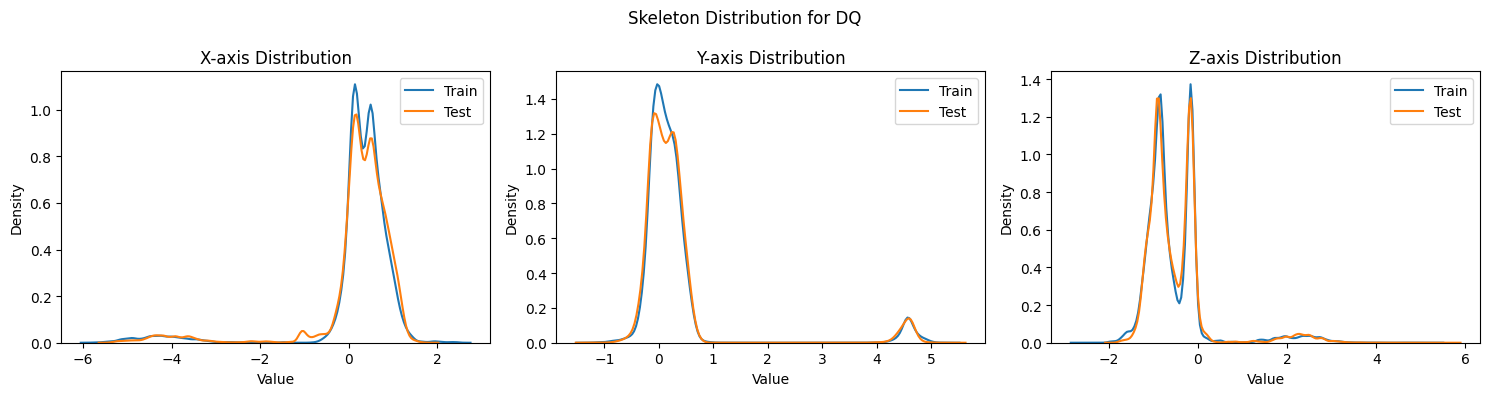

Percentage of zeroes in capactive train data for DQ:  0.0
Percentage of zeroes in capacitive test data for DQ:  0.0


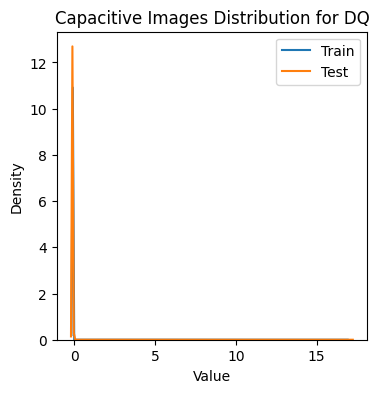

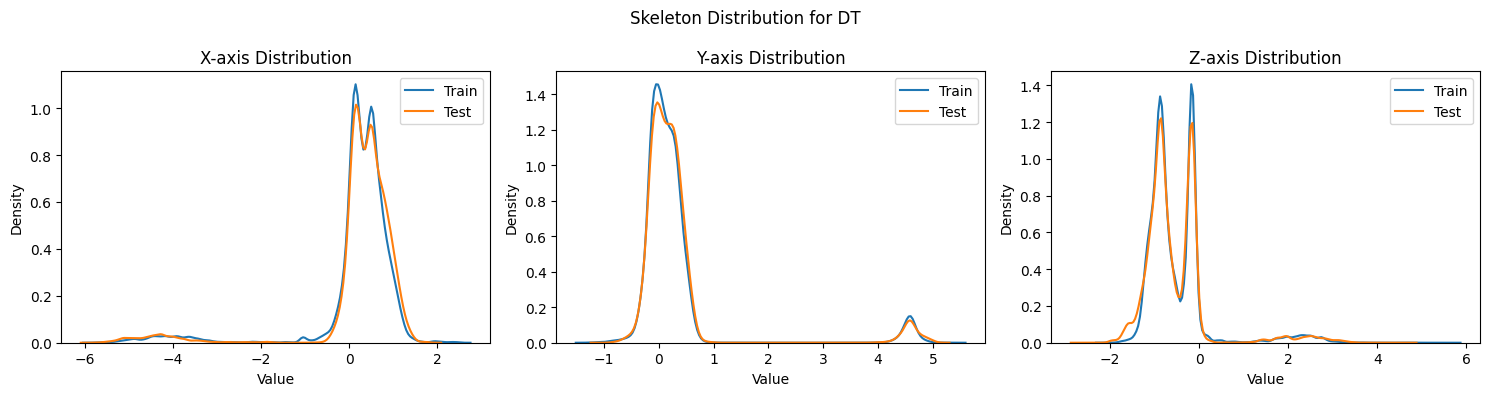

Percentage of zeroes in capactive train data for DT:  0.0
Percentage of zeroes in capacitive test data for DT:  0.0


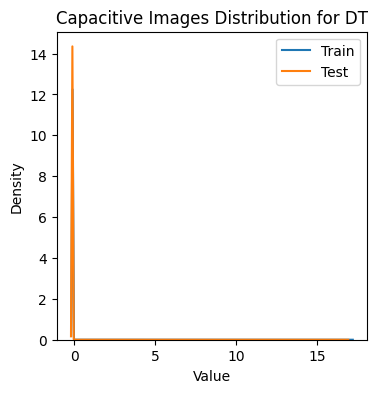

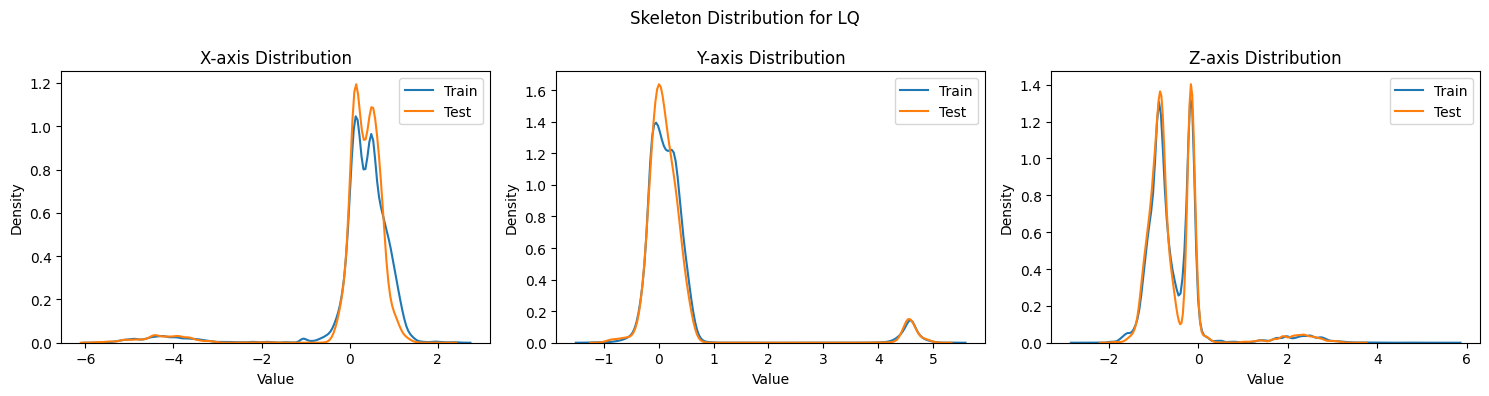

Percentage of zeroes in capactive train data for LQ:  0.0
Percentage of zeroes in capacitive test data for LQ:  0.0


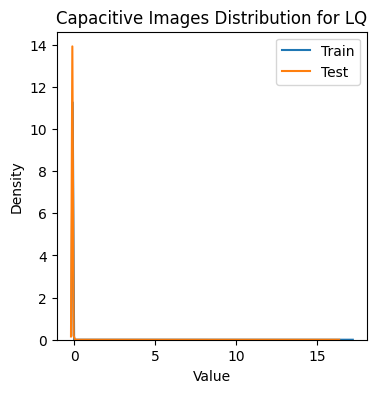

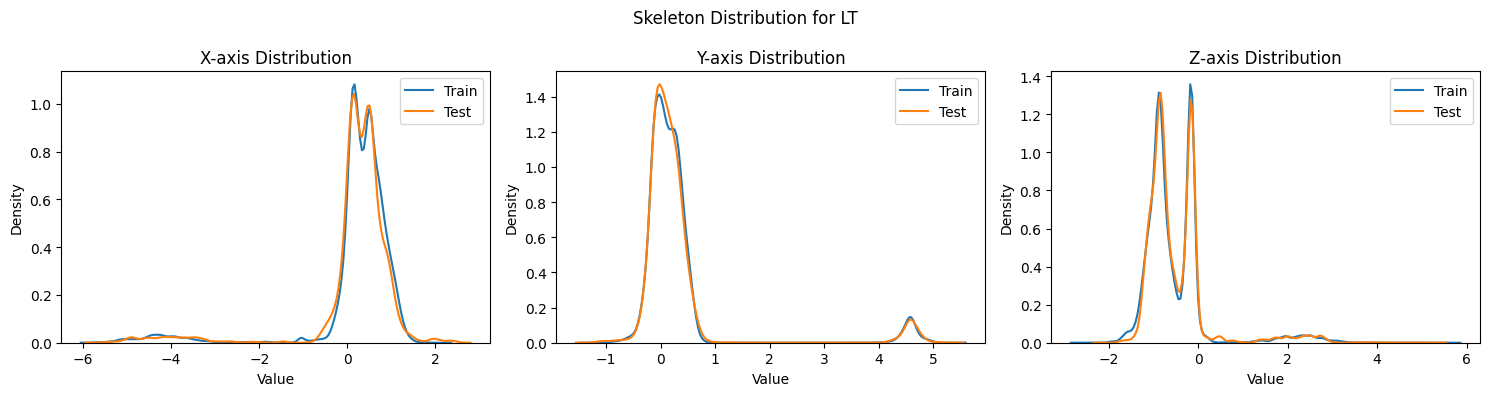

Percentage of zeroes in capactive train data for LT:  0.0
Percentage of zeroes in capacitive test data for LT:  0.0


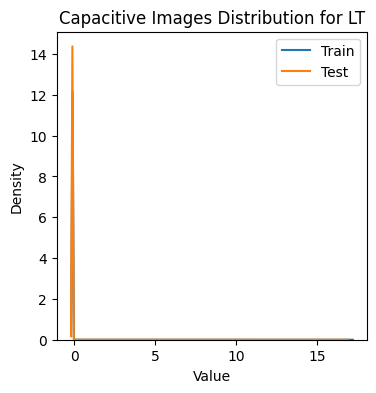

In [ ]:
for g in chili_data.gesture.unique() :
    train = shuffle(chili_data[chili_data.gesture!=g].copy(),random_state=42)
    test = shuffle(chili_data[chili_data.gesture==g].copy(),random_state=42)
    train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

    #skeleton distributions
    y_train_skel = y_train_skeleton.reshape(-1,21,3)
    y_test_skel = y_test_skeleton.reshape(-1,21,3)
    x_train,y_train,z_train = y_train_skel[:,:,0], y_train_skel[:,:,1], y_train_skel[:,:,2]
    x_test,y_test,z_test = y_test_skel[:,:,0], y_test_skel[:,:,1], y_test_skel[:,:,2]
    plt.figure(figsize=(15, 4))
    train_axes = [x_train,y_train,z_train]
    test_axes = [x_test,y_test,z_test]
    axes = ['X','Y','Z']
    for i in range(1,4):
        plt.subplot(1, 3, i)
        sns.kdeplot(train_axes[i-1].flatten(), label='Train')
        sns.kdeplot(test_axes[i-1].flatten(), label='Test')
        plt.title(axes[i-1]+'-axis Distribution')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()

    plt.suptitle('Skeleton Distribution for '+str(g))
    plt.legend()
    plt.tight_layout()
    plt.show()

    #capacitive images distributions
    plt.figure(figsize=(4, 4))
    train_cap_data = X_train.flatten()
    index = np.argwhere(train_cap_data==0)
    train_zeroes= (len(index)/len(train_cap_data))*100
    train_cap_data = np.delete(train_cap_data,index)
    test_cap_data =X_test.flatten()
    index = np.argwhere(test_cap_data==0)
    test_zeroes= (len(index)/len(test_cap_data))*100
    test_cap_data = np.delete(test_cap_data,index)
    sns.kdeplot(train_cap_data,label='Train')
    sns.kdeplot(test_cap_data,label='Test')
    plt.title('Capacitive Images Distribution for '+str(g))
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    print(f'Percentage of zeroes in capactive train data for {g}: ',train_zeroes)
    print(f'Percentage of zeroes in capacitive test data for {g}: ',test_zeroes)


# Cross validation subject model

In [ ]:
for s in [1,2,10,11,12,22,24,25] :
    model = load_model(chili_models+'3d_models/crossSubject/crossmulti_beta0.2_'+str(s)+'.h5',compile=False)
    print('test set on subject '+str(s))
    test = shuffle(chili_data[chili_data.subject==s].copy(),random_state=42)
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
    y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
    skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
    auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
    epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
    y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
    y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
    gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
    gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1_score)
    print("Mean Error: ",skeleton_error)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print('*'*50)

In [ ]:
for s in [1,2,10,11,12,22,24,25] :
    model = load_model(chili_models+'3d_models/crossSubject/crossmulti_beta0.2_'+str(s)+'.h5',compile=False)
    print('test set on subject '+str(s))
    test = shuffle(chili_data[chili_data.subject==s].copy(),random_state=42)
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
    y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
    skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
    auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
    epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
    y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
    y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
    gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
    gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1_score)
    print("Mean Error: ",skeleton_error)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print('*'*50)

test set on subject 1
Gesture Accuracy:  0.3333333333333333
Gesture F1 Score:  0.5
Mean Error:  26.544943
AucPCK :  [0. 0. 0. 0. 0. 0. 0.]
End point error  267.6703
**************************************************
test set on subject 2
Gesture Accuracy:  0.21033544877606528
Gesture F1 Score:  0.3109077216058177
Mean Error:  30.438606
AucPCK :  [0.         0.         0.         0.         0.04533092 0.09066183
 0.13599275]
End point error  282.98114
**************************************************
test set on subject 10
Gesture Accuracy:  0.11797307996832937
Gesture F1 Score:  0.21104815864022658
Mean Error:  24.49932
AucPCK :  [0. 0. 0. 0. 0. 0. 0.]
End point error  244.18512
**************************************************
test set on subject 11
Gesture Accuracy:  0.2449332674246169
Gesture F1 Score:  0.22446683548596125
Mean Error:  19.044209
AucPCK :  [0.         0.         0.         0.07414731 0.56846267 1.4582304
 2.7187345 ]
End point error  198.99962
*********************

# Time model

In [ ]:
model = load_model(chili_models+'3d_models/keep_wrist/base.h5',compile=False)
data = load_data(chili_data, 'time', 0.6, seed)
unnorm_test_chili = un_normchili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.2*len(x)))).reset_index(drop=True)
unnorm_test_chili

,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-235.8541717529297, 306.91522216796875, 162....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DQ,1,2803
1,1.680001e+12,"[[-130.8015594482422, 259.0377197265625, 25.87...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DT,2,2803
2,1.680001e+12,"[[-131.40338134765625, 258.8670654296875, 26.2...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DT,2,2803
3,1.680001e+12,"[[-131.2233428955078, 259.01629638671875, 26.2...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DT,2,2803
4,1.680001e+12,"[[-131.1776580810547, 259.0068664550781, 26.51...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DT,2,2803
...,...,...,...,...,...,...,...
16184,1.680527e+12,"[[-288.7589416503906, 286.1890563964844, 171.7...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304
16185,1.680527e+12,"[[-289.0491943359375, 286.4190979003906, 171.4...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304
16186,1.680527e+12,"[[-288.4601745605469, 285.4347839355469, 171.5...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304
16187,1.680527e+12,"[[-289.1985168457031, 285.461181640625, 184.38...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304


In [ ]:
y_test = data['test']['y']
y_out = model.predict(data['test']['X'], batch_size=32)
y_test_skeleton, y_out_skeleton = y_test[:,:63], y_out[:,:63]
epe_max = sorted_sample_end_point_error(y_test_skeleton,y_out_skeleton, mean, std)
epe_max

506/506 [==============================] - 25s 49ms/step


TopKV2(values=<tf.Tensor: shape=(16189,), dtype=float64, numpy=
array([526.66420907, 524.47019275, 520.2806795 , ...,  16.6452854 ,
        15.16784514,  14.04989823])>, indices=<tf.Tensor: shape=(16189,), dtype=int32, numpy=array([  195, 10930,  9990, ..., 11721, 13313, 13970], dtype=int32)>)

In [ ]:
worst, best = epe_max.indices[epe_max.values>275], epe_max.indices[epe_max.values<30]
print(len(best), len(worst))

136 1260


In [ ]:
unnorm_test_chili.loc[best].cap_img.apply(lambda x : len(x[x!=0])).describe()

count    136.000000
mean      45.242647
std       46.355550
min        2.000000
25%       19.000000
50%       33.500000
75%       60.250000
max      309.000000
Name: cap_img, dtype: float64

In [ ]:
unnorm_test_chili.loc[worst].cap_img.apply(lambda x : len(x[x!=0])).describe()

count    1260.000000
mean       43.790476
std        33.312737
min         1.000000
25%        22.000000
50%        40.000000
75%        61.000000
max       315.000000
Name: cap_img, dtype: float64

In [ ]:
unnorm_test_chili.loc[best].cap_img.apply(lambda x : np.mean(x)).describe()

count    136.000000
mean      10.338235
std       11.720034
min        0.251355
25%        3.880589
50%        8.075711
75%       13.003133
max       83.733740
Name: cap_img, dtype: float64

In [ ]:
unnorm_test_chili.loc[worst].cap_img.apply(lambda x : np.mean(x)).describe()

count    1260.000000
mean        9.849075
std         8.167061
min         0.035908
25%         4.940379
50%         9.031504
75%        12.916582
max        85.714092
Name: cap_img, dtype: float64

**Compare true and prediced labels between best and worst predicted samples**   
The epe in the following section changes since the wrist missprediction is propagated to the other joints



In [ ]:
y_trues = y_test_skeleton.numpy()[best]*std + mean
y_preds = y_out_skeleton[best]*std + mean
wrist1 = np.tile(y_preds[:,:3], (1, 21))
wrist2 = np.tile(y_trues[:,:3], (1, 21))
wrist1[:,:3] = 0
wrist2[:,:3] = 0
y_preds += wrist1
y_trues += wrist2

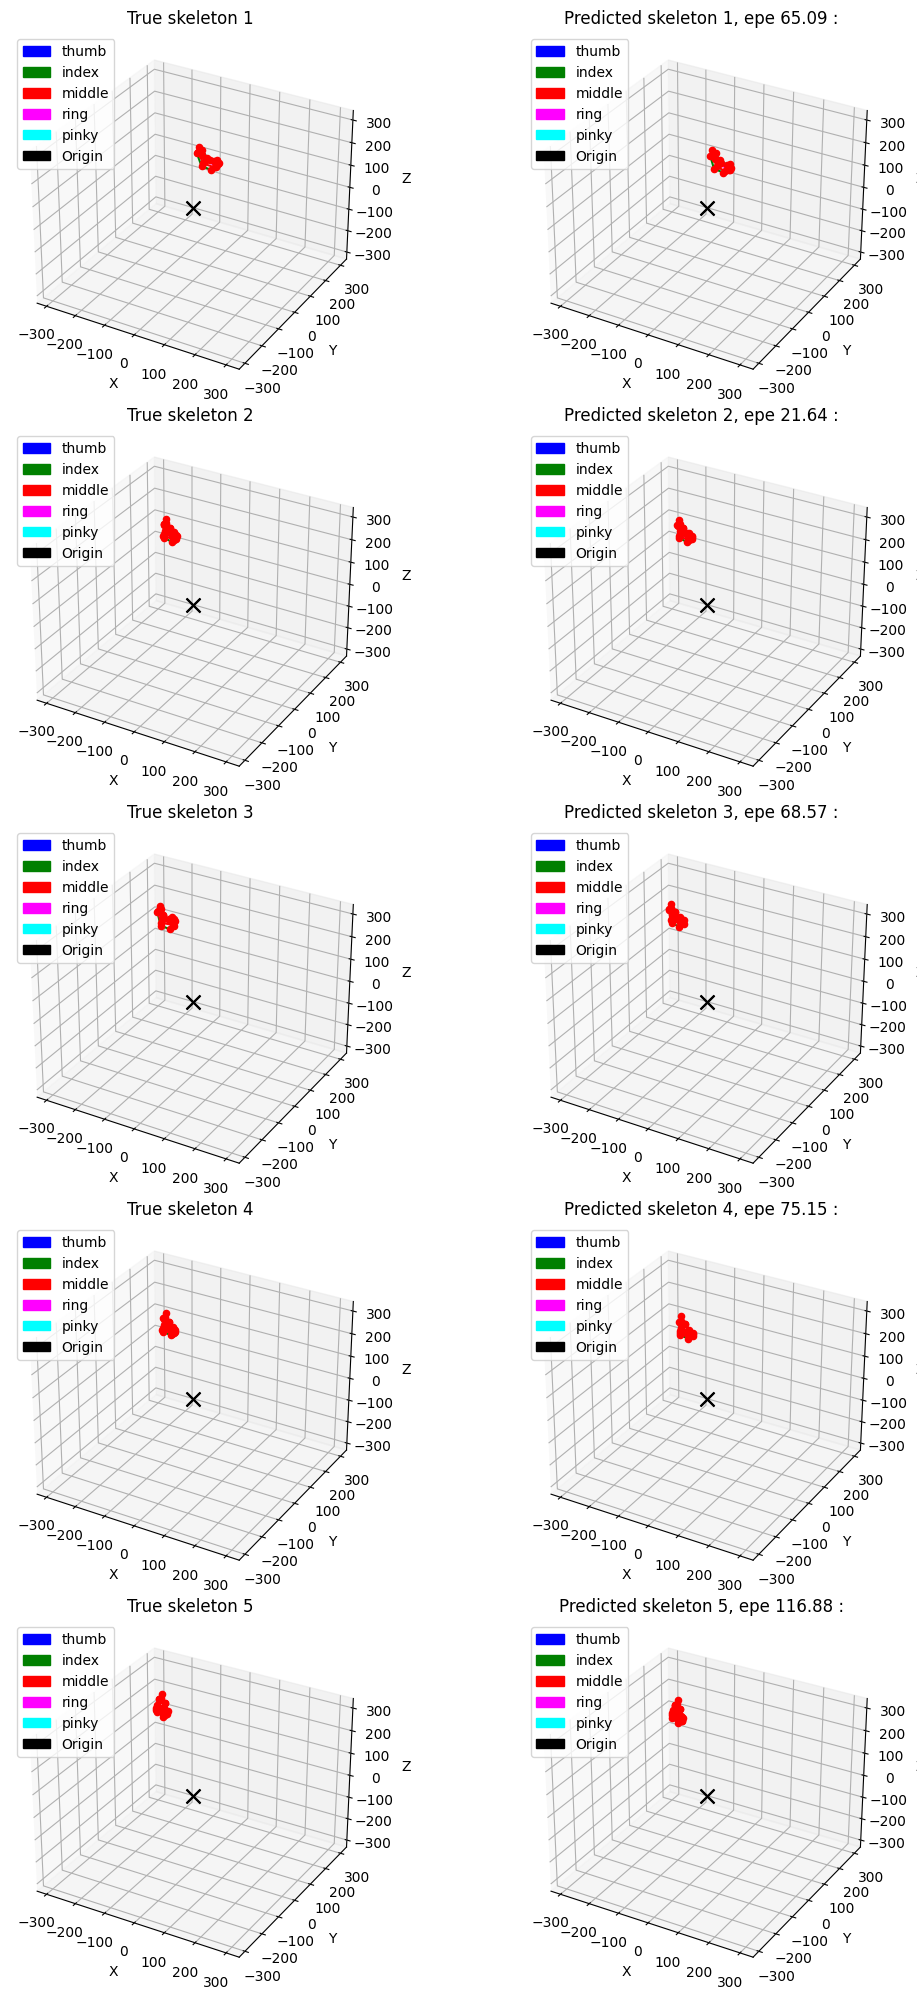

In [ ]:
plot_hand_compare(y_trues,y_preds, same_axis=True)

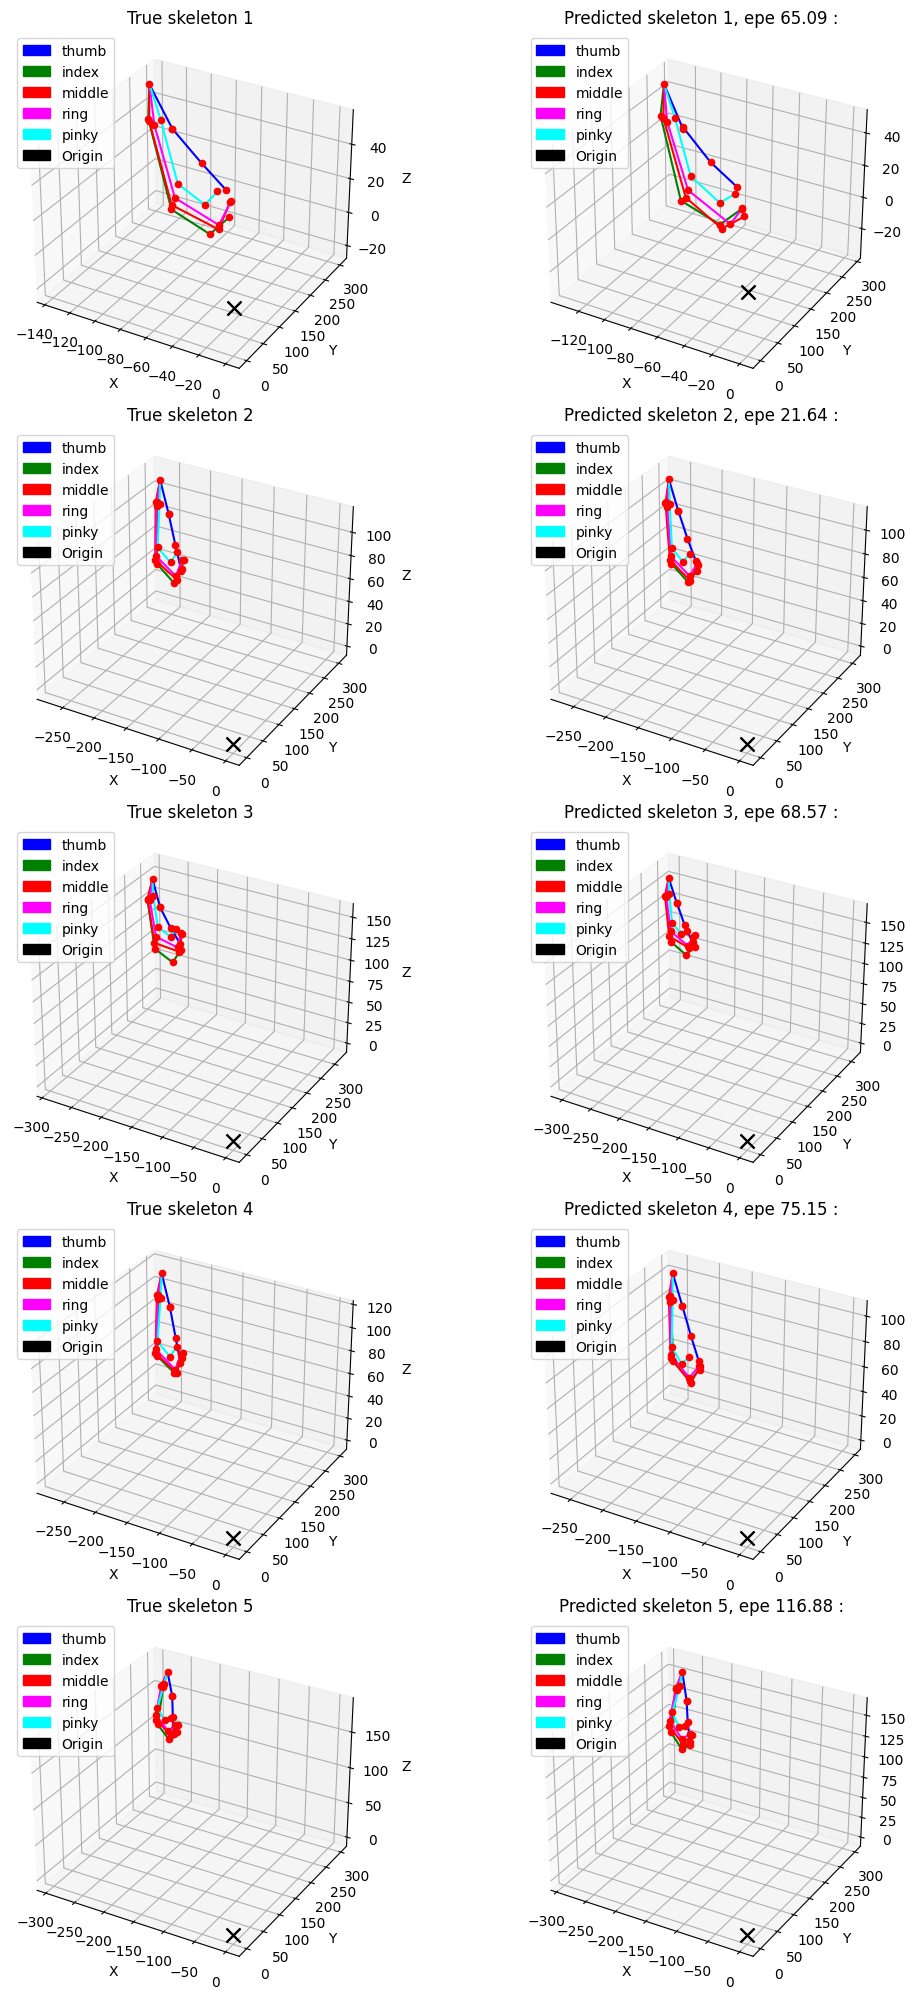

In [ ]:
plot_hand_compare(y_trues,y_preds)

**worst**

In [ ]:
y_trues = y_test_skeleton.numpy()[worst]*std + mean
y_preds = y_out_skeleton[worst]*std + mean
wrist1 = np.tile(y_preds[:,:3], (1, 21))
wrist2 = np.tile(y_trues[:,:3], (1, 21))
wrist1[:,:3] = 0
wrist2[:,:3] = 0
y_preds += wrist1
y_trues += wrist2

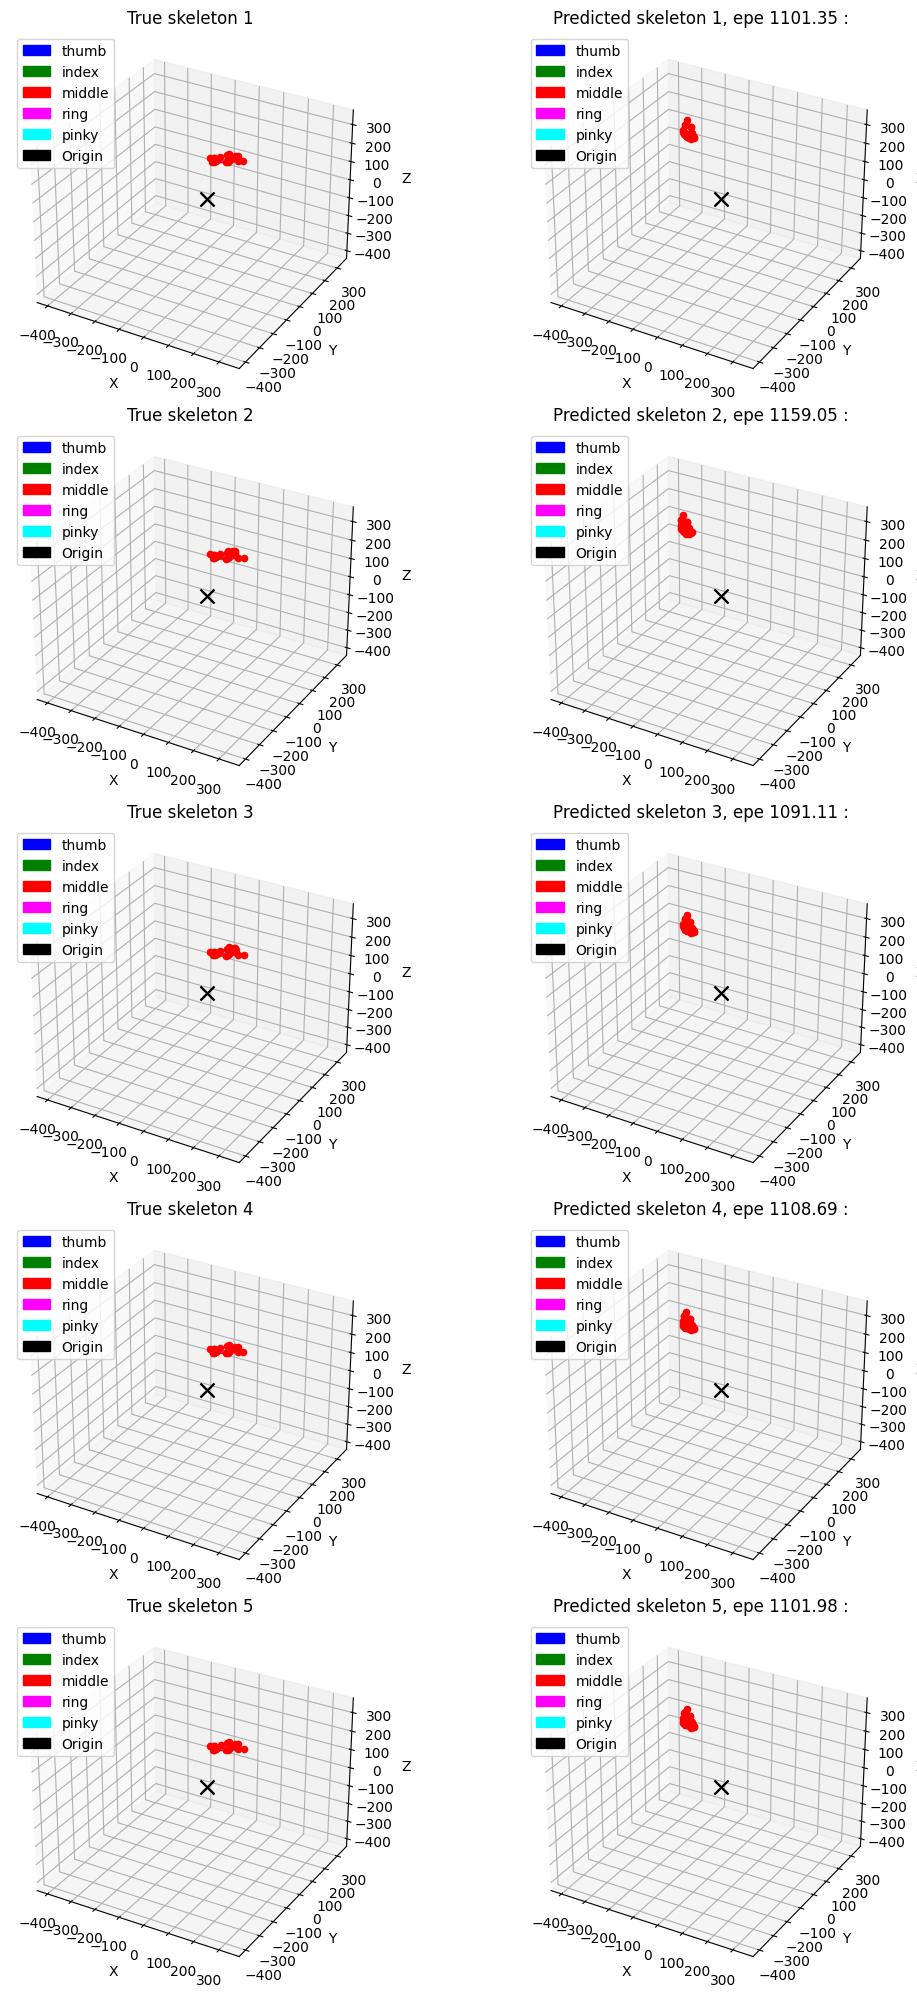

In [ ]:
plot_hand_compare(y_trues,y_preds, same_axis=True)

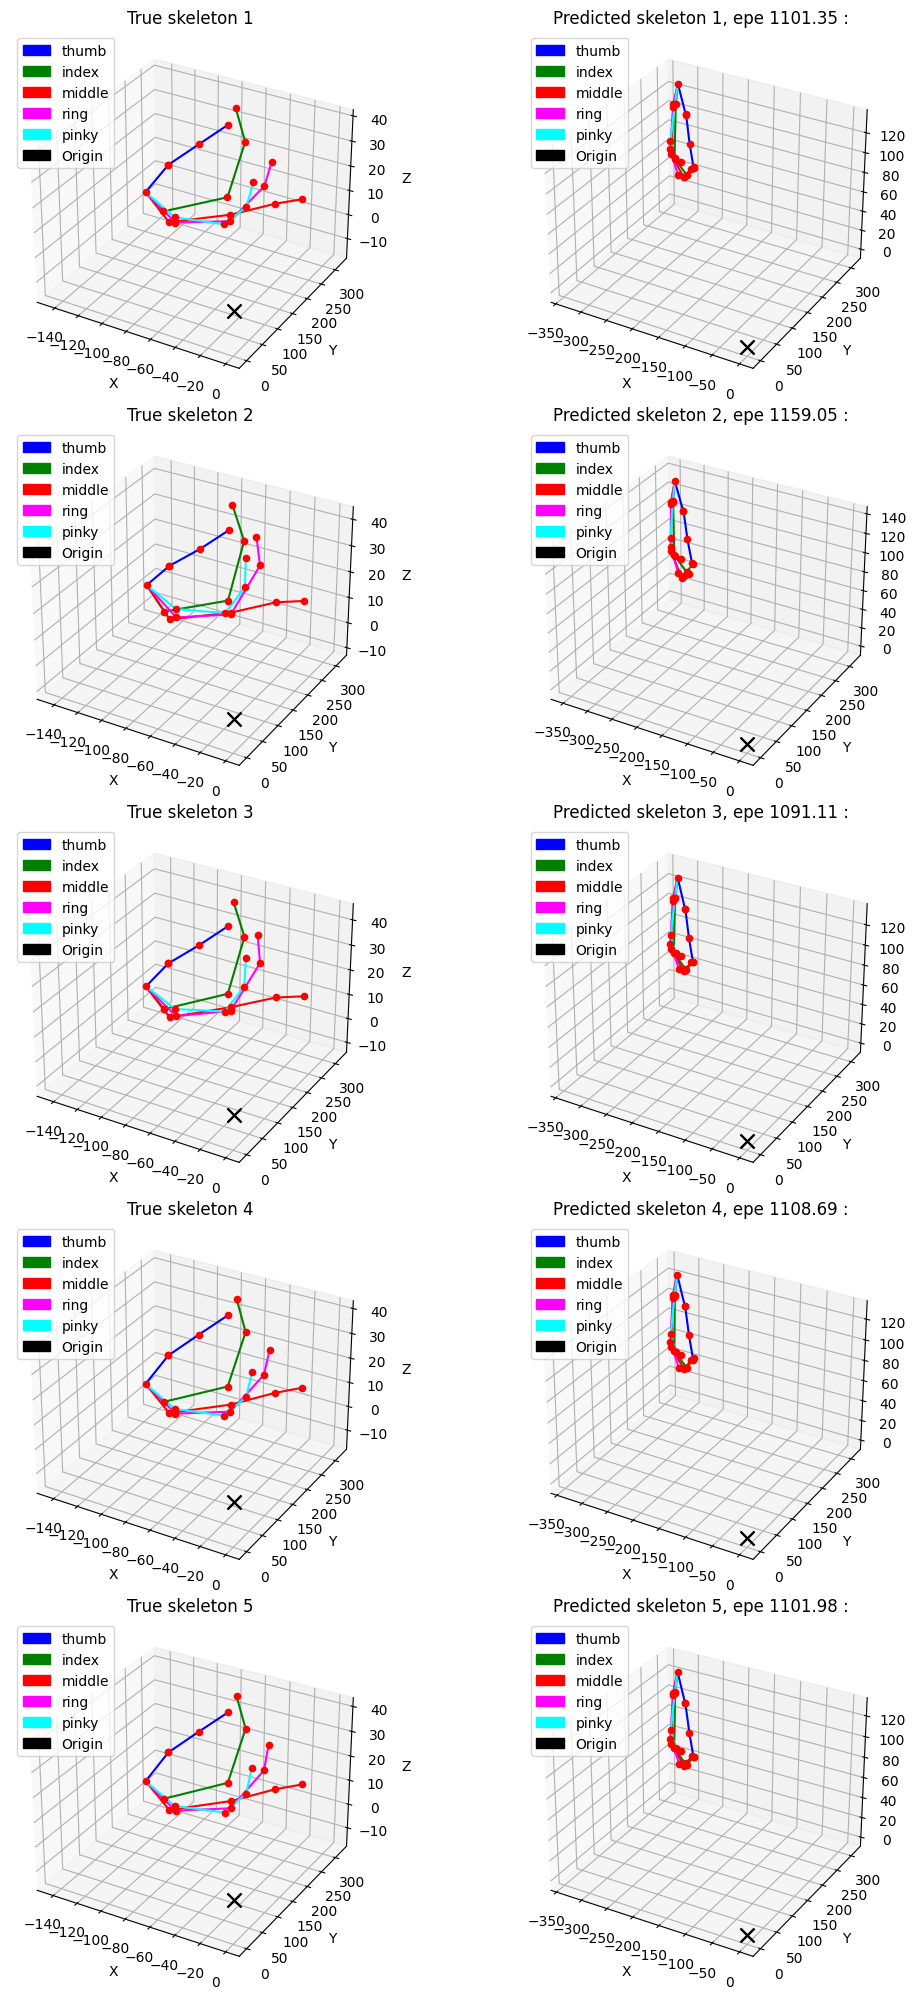

In [ ]:
#lloks like a left hand?
plot_hand_compare(y_trues,y_preds)

**compare capacitive images and skeleton of both best and worst groups**

In [ ]:
for i in range(20) :
  sample = unnorm_test_chili.loc[best].iloc[i]
  plot_skel_cap_img(sample.skeleton,sample.cap_img,camera_coords=True, title= 'best predicted samples')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for i in range(20) :
  sample = unnorm_test_chili.loc[worst].iloc[i]
  plot_skel_cap_img(sample.skeleton,sample.cap_img,camera_coords=True, title ='worst predicted samples')

Output hidden; open in https://colab.research.google.com to view.

**print both with same axis**

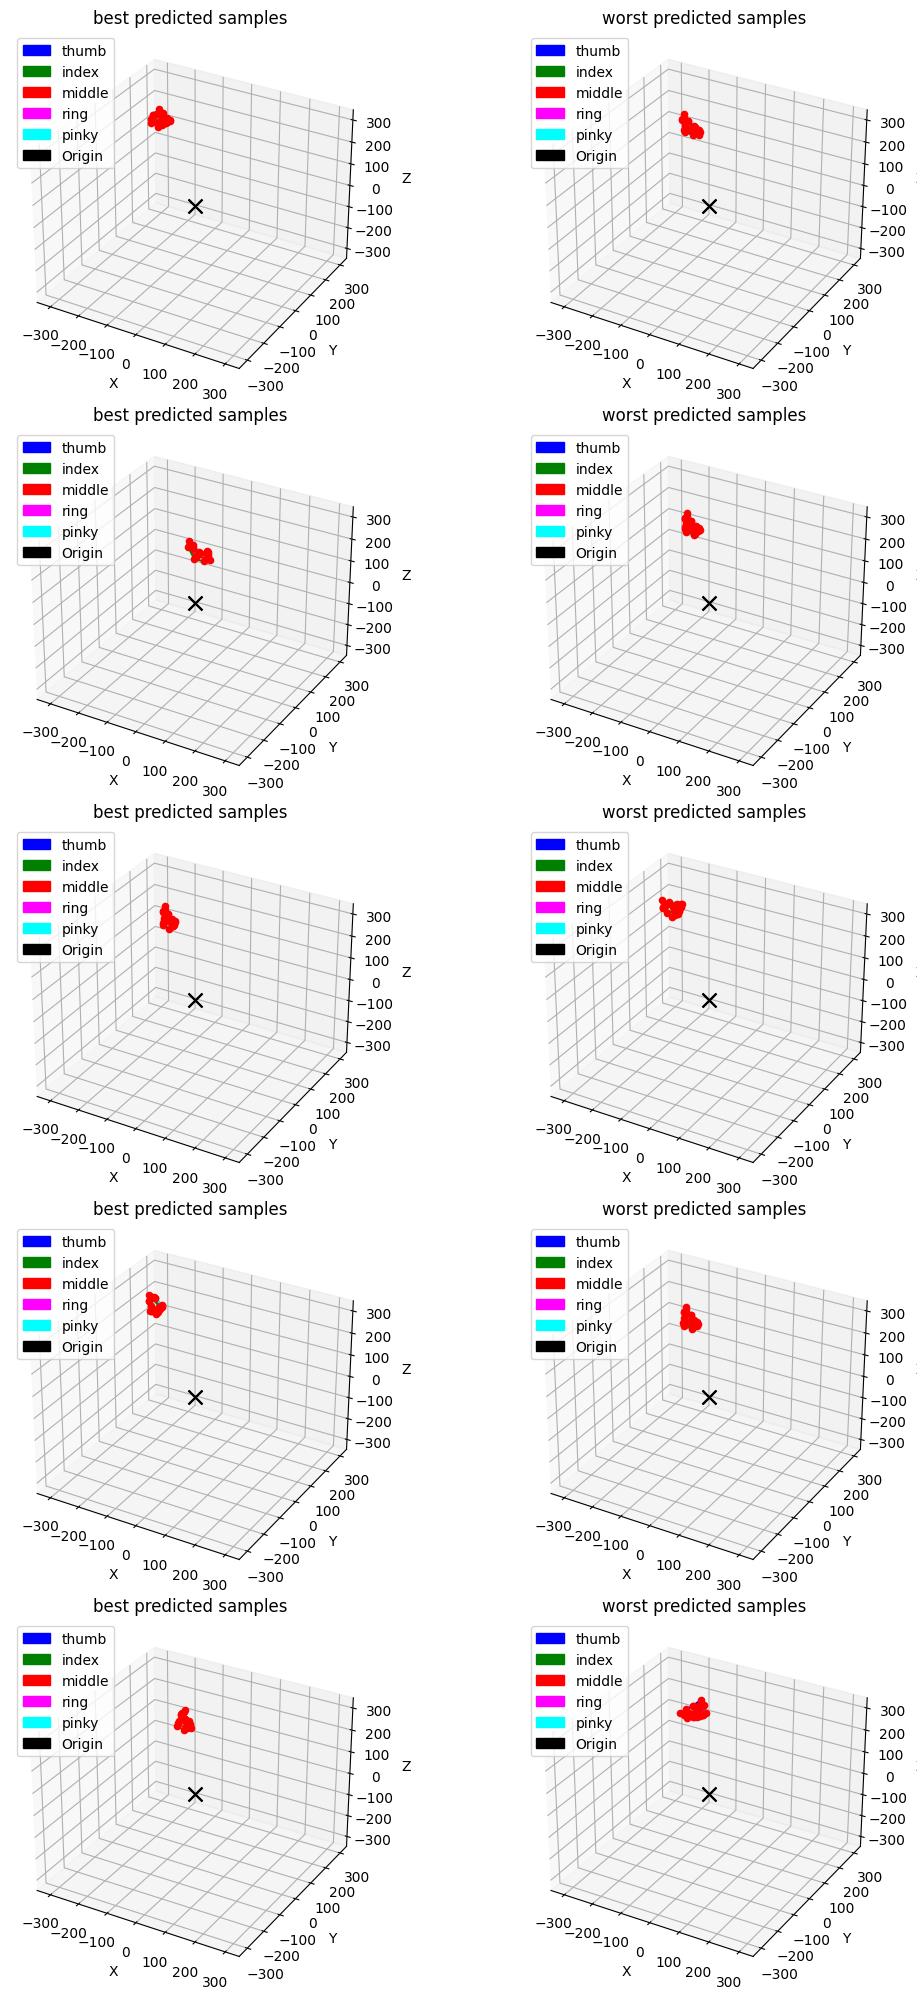

In [ ]:
sample_good = np.stack(unnorm_test_chili.loc[best].iloc[:5].skeleton.values)
sample_bad = np.stack(unnorm_test_chili.loc[worst].iloc[:5].skeleton.values)
plot_hand_compare(sample_good,sample_bad, title1 ='best predicted samples', title2='worst predicted samples', same_axis=True)

**without same axis**

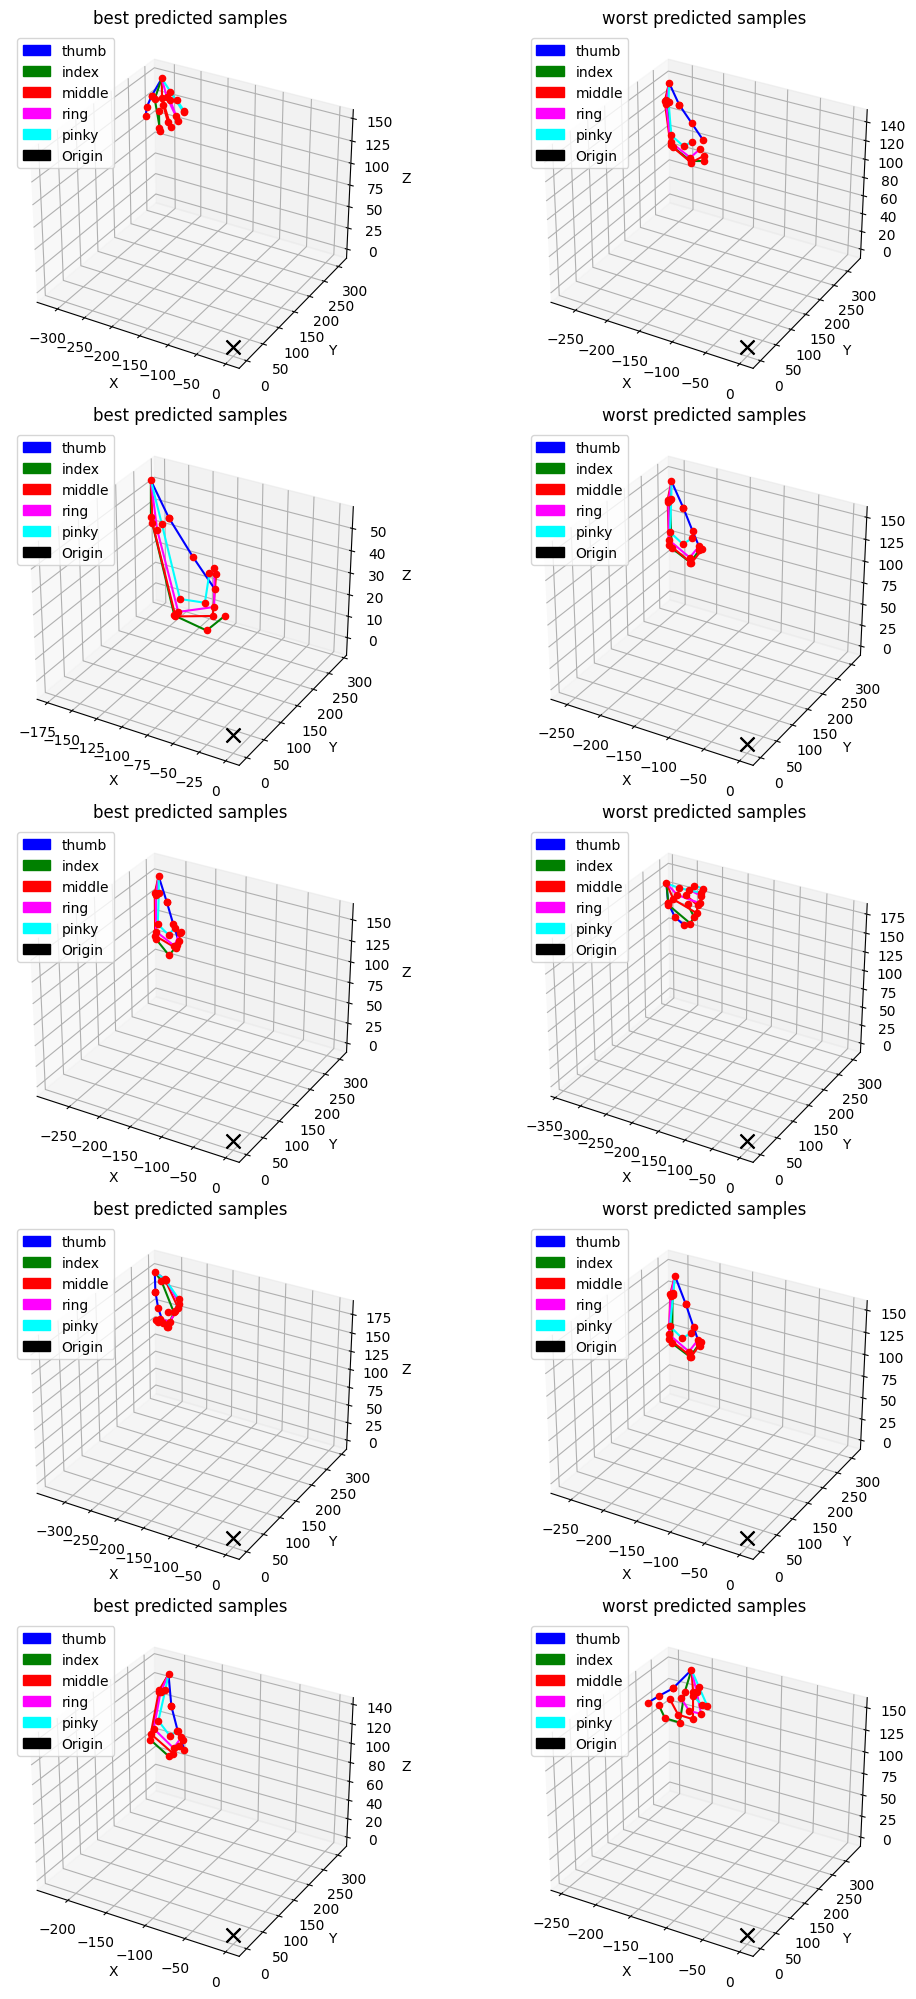

In [ ]:
plot_hand_compare(sample_good,sample_bad, title1 ='best predicted samples', title2='worst predicted samples')